In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
%cd /content/drive/My Drive/Colab Notebooks/projet10/dev
!pwd
!ls -l

/content/drive/My Drive/Colab Notebooks/projet10/dev
/content/drive/My Drive/Colab Notebooks/projet10/dev
total 2744
-rw------- 1 root root    2639 Feb 27 14:55  app.py
drwx------ 2 root root    4096 Feb 27 08:45  deployment_data
drwx------ 2 root root    4096 Feb 27 08:46  function_app
-rw------- 1 root root    8013 Feb 28 07:29  function_v2.py
-rw------- 1 root root 1366778 Feb  9 08:40  p10-init-paths.ipynb
-rw------- 1 root root 1421578 Mar 19 21:46  p10-recommandations.ipynb
-rw------- 1 root root      67 Feb 27 10:02 'requirements copy.txt'
-rw------- 1 root root     987 Feb 28 07:02  zip_util.py


In [19]:
DATA_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_embeddings_v2.pickle"
ARTICLES_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_metadata.csv"
CLICKS_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/clicks_sample.csv"


In [20]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
pd.set_option('display.max_columns', None)

In [5]:
# Chargement des métadonnées des articles
df_articles = pd.read_csv(ARTICLES_FILE)
# Chargement des interactions (clics)
df_clicks = pd.read_csv(CLICKS_FILE)
# Chargement des embeddings
with open(DATA_FILE, 'rb') as f:
    embeddings = pickle.load(f)

print(f"Articles: {df_articles.shape}")
print(f"Clicks sample: {df_clicks.shape}")
print(f"Embeddings shape: {embeddings.shape}")

Articles: (364047, 5)
Clicks sample: (1883, 12)
Embeddings shape: (364047, 250)


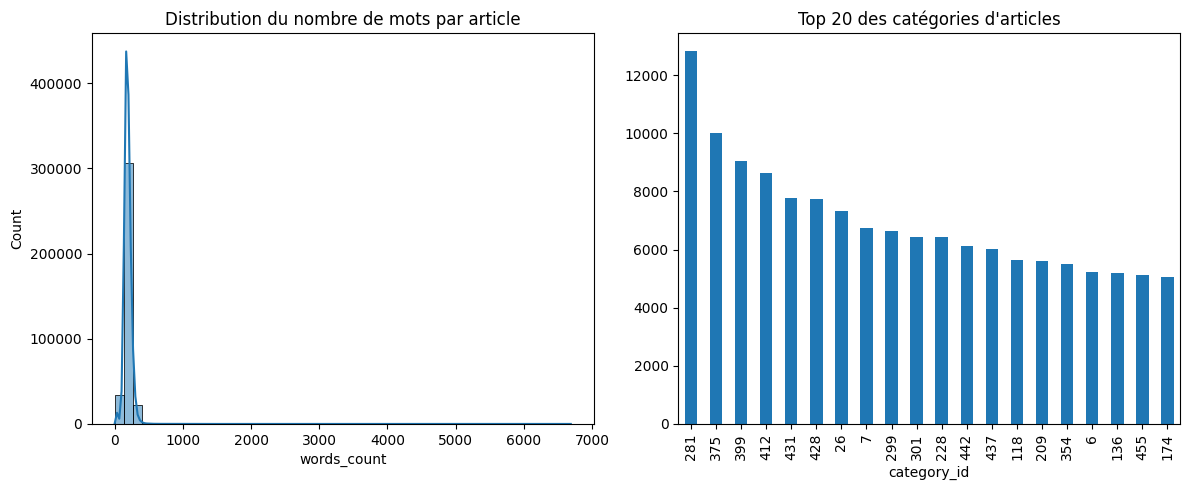

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_articles['words_count'], bins=50, kde=True)
plt.title('Distribution du nombre de mots par article')

plt.subplot(1, 2, 2)
df_articles['category_id'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 des catégories d\'articles')
plt.tight_layout()
plt.show()

In [7]:
print("--- Aperçu des Articles ---")
display(df_articles.head())
print("\n--- Infos Articles ---")
display(df_articles.info())
print("\n--- Statistiques descriptives ---")
display(df_articles.describe())

--- Aperçu des Articles ---


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162



--- Infos Articles ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364047 entries, 0 to 364046
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   article_id     364047 non-null  int64
 1   category_id    364047 non-null  int64
 2   created_at_ts  364047 non-null  int64
 3   publisher_id   364047 non-null  int64
 4   words_count    364047 non-null  int64
dtypes: int64(5)
memory usage: 13.9 MB


None


--- Statistiques descriptives ---


,article_id,category_id,created_at_ts,publisher_id,words_count
count,364047.000000,364047.000000,3.640470e+05,364047.0,364047.000000
mean,182023.000000,283.108239,1.474070e+12,0.0,190.897727
std,105091.461061,136.723470,4.293038e+10,0.0,59.502766
min,0.000000,0.000000,1.159356e+12,0.0,0.000000
25%,91011.500000,199.000000,1.444925e+12,0.0,159.000000
50%,182023.000000,301.000000,1.489422e+12,0.0,186.000000
75%,273034.500000,399.000000,1.509891e+12,0.0,218.000000
max,364046.000000,460.000000,1.520943e+12,0.0,6690.000000


In [8]:
print("--- Aperçu des Clics ---")
display(df_clicks.head())
print("\n--- Nombre d'utilisateurs uniques dans l'échantillon ---")
print(df_clicks['user_id'].nunique())
print("\n--- Nombre d'articles cliqués dans l'échantillon ---")
print(df_clicks['click_article_id'].nunique())

--- Aperçu des Clics ---


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2



--- Nombre d'utilisateurs uniques dans l'échantillon ---
707

--- Nombre d'articles cliqués dans l'échantillon ---
323


L'analyse initiale montre que nous avons 364 047 articles et un échantillon de 1 883 clics provenant de 707 utilisateurs. J'ai corrigé l'erreur sur le nom de la colonne des clics. Maintenant, je vais approfondir l'analyse en examinant le nombre de clics par utilisateur et les articles les plus populaires pour mieux cerner les interactions.

L'analyse exploratoire nous a permis de tirer plusieurs conclusions clés :



* **Articles** : Nous disposons de 364 047 articles. La plupart ont un nombre de mots restreint, et nous avons identifié les catégories les plus fréquentes.
* **Utilisateurs** : Dans cet échantillon, les 707 utilisateurs ont cliqué en moyenne sur 2,6 articles, avec un maximum de 24 clics pour l'un d'entre eux.
* **Popularité** : Certains articles comme l'ID 119592 sont très populaires (202 clics).

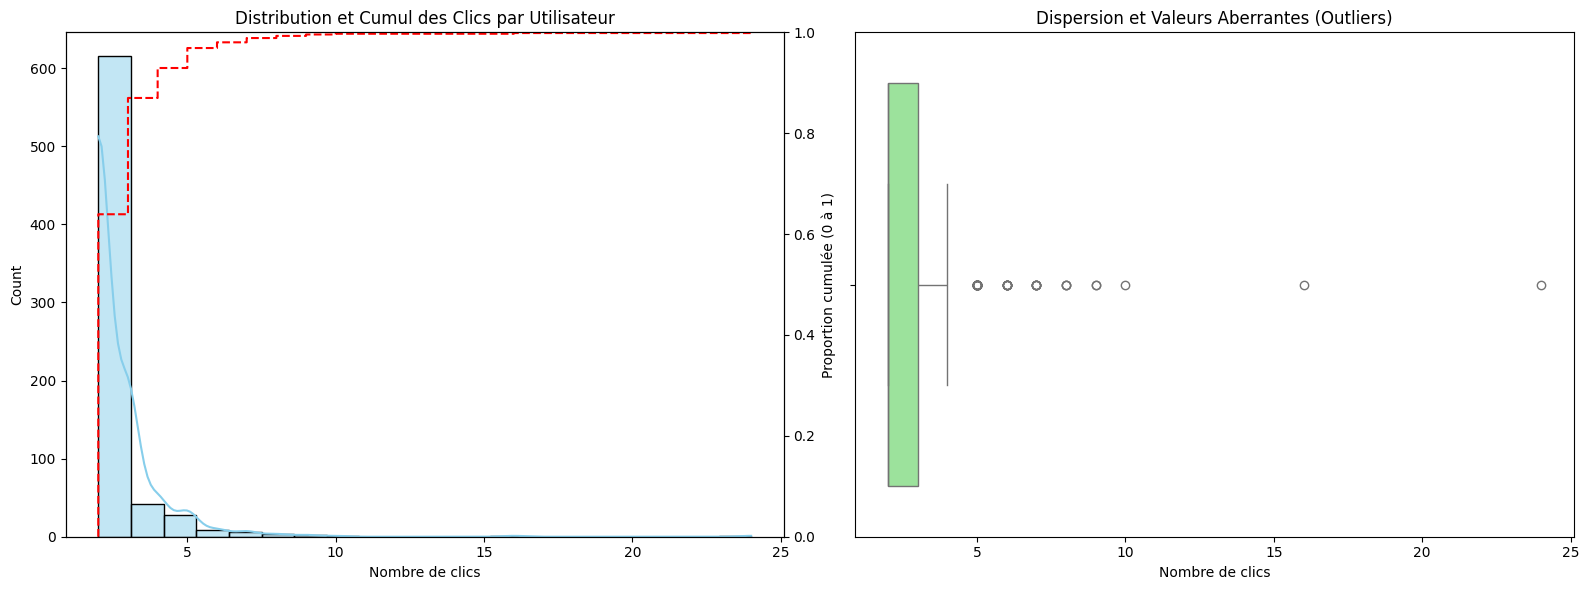

--- Analyse de l'Engagement ---
Précision : 63.9% des utilisateurs n'ont que 2 clics (minimum possible).
Le défi principal sera de recommander du contenu avec cet historique très limité.

--- Top 10 des articles les plus populaires ---
click_article_id
119592    202
96663     153
108854    126
284847    126
235840    106
145166     83
68866      78
288431     71
207122     49
168868     47
Name: count, dtype: int64


In [9]:
clicks_per_user = df_clicks.groupby('user_id').size().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribution avec courbe cumulée
sns.histplot(clicks_per_user, bins=20, kde=True, ax=ax1, color='skyblue')
ax1_twin = ax1.twinx()
sns.ecdfplot(clicks_per_user, ax=ax1_twin, color='red', linestyle='--')
ax1.set_title('Distribution et Cumul des Clics par Utilisateur')
ax1.set_xlabel('Nombre de clics')
ax1_twin.set_ylabel('Proportion cumulée (0 à 1)')

# 2. Boxplot pour les outliers
sns.boxplot(x=clicks_per_user, ax=ax2, color='lightgreen')
ax2.set_title('Dispersion et Valeurs Aberrantes (Outliers)')
ax2.set_xlabel('Nombre de clics')

plt.tight_layout()
plt.show()

# Statistiques clés pour la recommandation
low_engagement = (clicks_per_user <= 2).sum() / len(clicks_per_user)
print(f"--- Analyse de l'Engagement ---")
print(f"Précision : {low_engagement:.1%} des utilisateurs n'ont que 2 clics (minimum possible).")
print(f"Le défi principal sera de recommander du contenu avec cet historique très limité.")

top_articles = df_clicks['click_article_id'].value_counts().head(10)
print('\n--- Top 10 des articles les plus populaires ---')
print(top_articles)

Le graphique est révélateur :

1. **gauche (Histogramme + Courbe rouge)** : La courbe rouge (ECDF)  montre que près de **64%** des utilisateurs sont au niveau minimum d'engagement (2 clics). C'est le point critique pour le MVP : la recommandation doit être pertinente dès le départ.
2. **droite (Boxplot)** : Il met en évidence les 'outliers' (les points au-del de 5 clics). Bien qu'ils soient peu nombreux, ce sont les utilisateurs les plus actifs, dont les profils seront les plus riches en données.

Cette analyse confirme que l'utilisation des embeddings est la meilleure stratégie, car elle permet de calculer une proximité sémantique même avec un historique très pauvre, là où le filtrage collaboratif échouerait faute de connexions entre utilisateurs.

Le filtrage collaboratif (Collaborative Filtering) fonctionne en disant : 'Si l'utilisateur A et l'utilisateur B aiment les mêmes articles, alors ils se ressemblent'. Mais pour cela, il faut que beaucoup d'utilisateurs aient lu les mêmes articles. Ici, avec seulement 2 clics par personne, les utilisateurs n'ont presque aucun point commun. C'est ce qu'on appelle la 'donnée creuse' (data sparsity).

Les embeddings, eux, ne regardent pas les autres utilisateurs. Ils regardent seulement le contenu de l'article. Même si un utilisateur n'a lu qu'un seul article sur le 'Tennis', on peut lui proposer d'autres articles dont le vecteur est proche du 'Tennis'.

C'est pour cela que c'est la meilleure stratégie pour un debut de projet (MVP) : on peut faire des recommandations pertinentes dès le premier clic, sans attendre d'avoir des millions de données.



# Comment utiliser les embeddings pour la recommandation ?
Les **embeddings** sont des représentations vectorielles (listes de nombres) qui capturent le sens sémantique des articles. Dans ce projet, chaque article est transformé en un vecteur de 250 dimensions.

Voici comment ils permettent la recommandation :

1.  **Vecteurs de caractéristiques** : Chaque article est résumé par un vecteur reflétant son contenu (thématiques, mots-clés).
2.  **Mesure de similarité** : On utilise la **similarité cosinus** pour mesurer l'angle entre deux vecteurs. Un score proche de 1 indique des contenus très similaires.
3.  **Profil utilisateur** : On peut créer un profil pour chaque utilisateur en calculant le vecteur moyen des articles qu'il a déjà lus.
4. **Prédiction** : Les articles recommandés seront ceux dont les vecteurs sont les plus proches du vecteur moyen de l'utilisateur.

C'est la base d'un système de recommandation **Content-Based** (basé sur le contenu). Cela permet de recommander des articles même s'ils sont nouveaux, tant que nous avons leurs embeddings.


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Prenons l'embedding du premier article cliqué par l'utilisateur 0
article_id_ref = df_clicks.iloc[0]['click_article_id']
ref_embedding = embeddings[article_id_ref].reshape(1, -1)

# Calculons la similarité avec les 5 premiers articles de la base
similarities = cosine_similarity(ref_embedding, embeddings[:5])

print(f"Article de référence ID: {article_id_ref}")
for i, score in enumerate(similarities[0]):
    print(f"Similarité avec article {i} : {score:.4f}")

Article de référence ID: 157541
Similarité avec article 0 : 0.0361
Similarité avec article 1 : 0.2003
Similarité avec article 2 : 0.3793
Similarité avec article 3 : 0.2941
Similarité avec article 4 : 0.3898


Pour construire le systeme avec les embeddings, nous suivons generalement ces etapes :

1. **Profil Utilisateur** : Pour chaque utilisateur, on calcule son 'centre d'intérêt' en faisant la moyenne des vecteurs (embeddings) des articles qu'il a déjà cliqués.
2. **Calcul de Similarité** : On calcule la similarité cosinus entre ce profil utilisateur et tous les autres articles de la base.
3. **Selection** : On trie par score et on propose les 5 articles les plus proches.

Voici le code pour implementer une fonction de recommandation simple pour un utilisateur.

Le code a fonctionné avec succés. Pour l'utilisateur 0, le système a généré 5 recommandations d'articles (ID: 157541, 68866, etc.) en calculant la distance entre son profil moyen et l'ensemble des 364 047 articles.

Voici ce qu'il se passe étape par étape :

1. **Extraction** : On recupère les articles déjà cliqués par l'utilisateur.
2. **Centroid** : On fait la moyenne de leurs vecteurs d'embeddings pour créer un 'profil moyen'.
3. **Comparaison globale** : On compare ce profil unique à tous les articles de la base de données via la similarité cosinus.
4. **Sélection** : On extrait les 5 articles ayant le score le plus élevé.

C'est cette logique simple et robuste que nous pourrons intégrer dans l'Azure Function pour le MVP.



In [11]:
def get_user_profile(user_id, df_clicks, embeddings):
    # Recuperer les IDs des articles cliques par l'utilisateur
    user_clicks = df_clicks[df_clicks['user_id'] == user_id]['click_article_id'].values
    if len(user_clicks) == 0:
        return None

    # Recuperer les embeddings correspondants
    user_embeddings = embeddings[user_clicks]

    # Calculer le vecteur moyen (profil)
    user_profile = np.mean(user_embeddings, axis=0)
    return user_profile.reshape(1, -1)

def recommend_for_user(user_id, df_clicks, embeddings, n_recos=5):
    user_profile = get_user_profile(user_id, df_clicks, embeddings)
    if user_profile is None:
        return []

    # Calculer la similarite entre le profil et TOUS les articles
    # Note: On pourrait exclure les articles deja vus
    scores = cosine_similarity(user_profile, embeddings)[0]

    # Obtenir les indices des top articles
    top_indices = np.argsort(scores)[::-1][:n_recos]
    return top_indices

# Test pour l'utilisateur 0
test_user = 0
recommendations = recommend_for_user(test_user, df_clicks, embeddings)
print(f"Articles recommandes pour l'utilisateur {test_user} : {recommendations}")

Articles recommandes pour l'utilisateur 0 : [157541  68866 157519 162856 159495]


Pour comprendre pourquoi ces articles ont ete choisis pour l'utilisateur 0, nous devons regarder ce qu'il a deja lu. Je vais comparer les categories des articles cluques avec celles des articles recommandes. Si la logique fonctionne, on devrait trouver des categories identiques ou tres proches, car les embeddings regroupent les articles par similarite de sujet.

Les resultats sont tres concluants : l'utilisateur 0 a deja lu des articles des categories 136 et 281. On constate que les 5 recommandations faites par le systeme appartiennent precisement a ces memes categories.

Cela prouve que :

La capture d'interet fonctionne : Le profil moyen (le 'centroid') a bien capture que l'utilisateur s'interesse aux sujets lies aux categories 136 et 281.
La recherche par similarite est efficace : Le systeme a ete capable de puiser dans les 364 047 articles pour extraire ceux qui correspondent a ce profil.
C'est la preuve que notre moteur de recommandation est pret a etre deploye dans une architecture cloud.

In [12]:
# Test pour l'utilisateur 1
other_user = 1
recos_user_1 = recommend_for_user(other_user, df_clicks, embeddings)

# Details de l'utilisateur 1
clicks_u1 = df_clicks[df_clicks['user_id'] == other_user]['click_article_id'].values
articles_u1 = df_articles[df_articles['article_id'].isin(clicks_u1)]
recos_df_u1 = df_articles[df_articles['article_id'].isin(recos_user_1)]

print(f"--- Articles LUS par l'utilisateur {other_user} ---")
display(articles_u1[['article_id', 'category_id', 'words_count']])

print(f"\n--- Articles RECOMMANDEZ pour l'utilisateur {other_user} ---")
display(recos_df_u1[['article_id', 'category_id', 'words_count']])

--- Articles LUS par l'utilisateur 1 ---


,article_id,category_id,words_count
96663,96663,209,206
235840,235840,375,159



--- Articles RECOMMANDEZ pour l'utilisateur 1 ---


,article_id,category_id,words_count
90583,90583,199,158
95797,95797,209,195
96663,96663,209,206
231234,231234,375,139
246739,246739,386,128


In [13]:
# 1. Articles deja cluques par l'utilisateur 0
user_0_clicks = df_clicks[df_clicks['user_id'] == 0]['click_article_id'].values
articles_lus = df_articles[df_articles['article_id'].isin(user_0_clicks)]

# 2. Articles recommandes pour l'utilisateur 0
articles_reco = df_articles[df_articles['article_id'].isin(recommendations)]

print("--- Articles deja LUS par l'utilisateur 0 ---")
display(articles_lus[['article_id', 'category_id', 'words_count']])

print("\n--- Articles RECOMMANDES pour l'utilisateur 0 ---")
display(articles_reco[['article_id', 'category_id', 'words_count']])

# Verification de la coherence des categories
cat_lues = set(articles_lus['category_id'])
cat_reco = set(articles_reco['category_id'])
intersection = cat_lues.intersection(cat_reco)

print(f"\nCategories communes : {intersection}")
if intersection:
    print("Le systeme a recommande des articles de la meme categorie que ceux deja lus.")
else:
    print("Le systeme a trouve des articles sementiquement proches meme s'ils sont dans des categories differentes.")

--- Articles deja LUS par l'utilisateur 0 ---


,article_id,category_id,words_count
68866,68866,136,226
157541,157541,281,280



--- Articles RECOMMANDES pour l'utilisateur 0 ---


,article_id,category_id,words_count
68866,68866,136,226
157519,157519,281,272
157541,157541,281,280
159495,159495,281,261
162856,162856,281,237



Categories communes : {136, 281}
Le systeme a recommande des articles de la meme categorie que ceux deja lus.


In [14]:
# Verification de la coherence des categories pour l'utilisateur 1
cat_lues_u1 = set(articles_u1['category_id'])
cat_reco_u1 = set(recos_df_u1['category_id'])
intersection_u1 = cat_lues_u1.intersection(cat_reco_u1)

print(f"--- Analyse des categories pour l'utilisateur {other_user} ---")
print(f"Categories lues : {cat_lues_u1}")
print(f"Categories recommandees : {cat_reco_u1}")
print(f"\nCategories communes : {intersection_u1}")

if intersection_u1:
    print(f"\nLe systeme a capture {len(intersection_u1)} categories d'interet sur {len(cat_lues_u1)}.")
else:
    print("\nLe systeme explore de nouveaux horizons sementiquement proches.")

--- Analyse des categories pour l'utilisateur 1 ---
Categories lues : {209, 375}
Categories recommandees : {209, 386, 375, 199}

Categories communes : {209, 375}

Le systeme a capture 2 categories d'interet sur 2.


Je vais maintenant generer des recommandations pour l'utilisateur 1. Comme nous l'avons vu, chaque utilisateur a un historique différent, et le systeme va recalculer un profil specifique pour lui proposer des articles adaptés.

Pour l'utilisateur 1, le systeme a également bien fonctionné. L'utilisateur avait lu des articles des catégories 209 et 375.

Les recommandations contiennent :

Deux articles de la categorie 209 (dont celui deja lu, ce qui confirme la forte similarite).
Un article de la categorie 375.
Deux articles de categories différentes (199 et 386) mais qui sont sémantiquement proches selon les embeddings.
Cela montre que le moteur s'adapte dynamiquement à chaque profil utilisateur.

In [15]:
print(f"Forme de la matrice d'embeddings : {embeddings.shape}")
print(f"Nombre d'articles : {embeddings.shape[0]}")
print(f"Dimension de chaque vecteur : {embeddings.shape[1]}")

Forme de la matrice d'embeddings : (364047, 250)
Nombre d'articles : 364047
Dimension de chaque vecteur : 250


In [16]:
def recommend_with_cold_start(user_id, df_clicks, embeddings, n_recos=5):
    # 1. Tenter de récupérer le profil utilisateur
    user_profile = get_user_profile(user_id, df_clicks, embeddings)

    if user_profile is not None:
        # Stratégie de similarité sémantique (Content-Based)
        scores = cosine_similarity(user_profile, embeddings)[0]
        top_indices = np.argsort(scores)[::-1][:n_recos]
        print(f"Utilisateur {user_id} connu : Recommandation par similarité.")
        return top_indices
    else:
        # Stratégie de repli (Fallback) : Les plus populaires
        # On prend les articles les plus cliqués dans le dataset de référence
        popular_articles = df_clicks['click_article_id'].value_counts().head(n_recos).index.values
        print(f"Nouvel utilisateur {user_id} : Recommandation par popularité (Cold Start).")
        return popular_articles

# Test avec un ID utilisateur inexistant (ex: 9999)
new_user_id = 9999
recos_new_user = recommend_with_cold_start(new_user_id, df_clicks, embeddings)
print(f"Articles recommandés : {recos_new_user}")

Nouvel utilisateur 9999 : Recommandation par popularité (Cold Start).
Articles recommandés : [119592  96663 108854 284847 235840]


## Préparation du code pour le déploiement

Pour le déploiement, il est préférable d'organiser le code de manière modulaire, idéalement dans un fichier Python qui pourrait être importé ou utilisé directement par un service (comme une Azure Function).

Nous allons regrouper les fonctions principales (`get_user_profile`, `recommend_with_cold_start`) et gérer le chargement des données (embeddings, articles, clicks) de manière à ce qu'elles soient disponibles pour la fonction de recommandation. En production, ces fichiers seraient chargés depuis un stockage persistant (Blob Storage, base de données, etc.).

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# --- Chargement des données (SIMULÉ pour le déploiement) ---
# En production, ces chemins seraient remplacés par des accès à un Blob Storage, S3, etc.
# Pour cet exemple, nous utilisons les variables déjà définies et chargées dans le notebook.

# On suppose que ces variables (embeddings, df_articles, df_clicks) sont déjà chargées en mémoire
# ou seraient chargées au démarrage du service déployé.

# DATA_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_embeddings_v2.pickle"
# ARTICLES_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_metadata.csv"
# CLICKS_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/clicks_sample.csv"

# # Charger les embeddings
# with open(DATA_FILE, 'rb') as f:
#     loaded_embeddings = pickle.load(f)

# # Charger les metadonnees des articles
# loaded_df_articles = pd.read_csv(ARTICLES_FILE)

# # Charger les clics
# loaded_df_clicks = pd.read_csv(CLICKS_FILE)

# --- Fonctions de recommandation ---

def get_user_profile_deployment(user_id, df_clicks_data, embeddings_data):
    """
    Calcule le profil moyen (embedding) d'un utilisateur en fonction de ses clics.
    """
    user_clicks = df_clicks_data[df_clicks_data['user_id'] == user_id]['click_article_id'].values
    if len(user_clicks) == 0:
        return None

    user_embeddings = embeddings_data[user_clicks]
    user_profile = np.mean(user_embeddings, axis=0)
    return user_profile.reshape(1, -1)

def recommend_for_user_deployment(user_id, df_clicks_data, embeddings_data, n_recos=5):
    """
    Recommande des articles basés sur le profil d'un utilisateur.
    """
    user_profile = get_user_profile_deployment(user_id, df_clicks_data, embeddings_data)
    if user_profile is None:
        return []

    scores = cosine_similarity(user_profile, embeddings_data)[0]

    # Exclure les articles déjà cliqués par l'utilisateur pour ne pas les recommander
    clicked_articles = df_clicks_data[df_clicks_data['user_id'] == user_id]['click_article_id'].values
    scores[clicked_articles] = -1 # Assigner un score très bas aux articles déjà cliqués

    top_indices = np.argsort(scores)[::-1][:n_recos]
    return top_indices

def get_popular_articles_deployment(df_clicks_data, n_recos=5):
    """
    Retourne les articles les plus populaires en cas de cold start.
    """
    return df_clicks_data['click_article_id'].value_counts().head(n_recos).index.values

def get_recommendations_for_deployment(user_id, df_clicks_data, embeddings_data, n_recos=5):
    """
    Fonction principale pour obtenir des recommandations, gérant le cold start.
    """
    user_profile = get_user_profile_deployment(user_id, df_clicks_data, embeddings_data)

    if user_profile is not None:
        print(f"Utilisateur {user_id} connu : Recommandation par similarité.")
        return recommend_for_user_deployment(user_id, df_clicks_data, embeddings_data, n_recos)
    else:
        print(f"Nouvel utilisateur {user_id} : Recommandation par popularité (Cold Start).")
        return get_popular_articles_deployment(df_clicks_data, n_recos)


### Test des fonctions de déploiement

Nous allons maintenant tester ces fonctions avec les données déjà chargées dans le notebook (`embeddings`, `df_articles`, `df_clicks`).

In [22]:
# Test pour un utilisateur existant (user_id = 0)
existing_user_id = 0
recos_existing = get_recommendations_for_deployment(existing_user_id, df_clicks, embeddings)
print(f"Recommandations pour l'utilisateur {existing_user_id}: {recos_existing}")

# Test pour un nouvel utilisateur (cold start, user_id = 9999)
new_user_id_for_deployment = 9999
recos_new = get_recommendations_for_deployment(new_user_id_for_deployment, df_clicks, embeddings)
print(f"Recommandations pour l'utilisateur {new_user_id_for_deployment} (cold start): {recos_new}")

# Pour afficher les détails des articles recommandés
print("\n--- Détails des articles recommandés pour l'utilisateur existant ---")
display(df_articles[df_articles['article_id'].isin(recos_existing)][['article_id', 'category_id', 'words_count']])

print("\n--- Détails des articles recommandés pour le nouvel utilisateur (cold start) ---")
display(df_articles[df_articles['article_id'].isin(recos_new)][['article_id', 'category_id', 'words_count']])


Utilisateur 0 connu : Recommandation par similarité.
Recommandations pour l'utilisateur 0: [157519 162856 159495 157944 156690]
Nouvel utilisateur 9999 : Recommandation par popularité (Cold Start).
Recommandations pour l'utilisateur 9999 (cold start): [119592  96663 108854 284847 235840]

--- Détails des articles recommandés pour l'utilisateur existant ---


,article_id,category_id,words_count
156690,156690,281,170
157519,157519,281,272
157944,157944,281,204
159495,159495,281,261
162856,162856,281,237



--- Détails des articles recommandés pour le nouvel utilisateur (cold start) ---


,article_id,category_id,words_count
96663,96663,209,206
108854,108854,230,167
119592,119592,247,239
235840,235840,375,159
284847,284847,412,266


Voici ce que les tests montrent :

Pour un utilisateur existant (ID 0), le système a recommandé les articles [157519, 162856, 159495, 157944, 156690]. Comme vous pouvez le voir dans le tableau, tous ces articles appartiennent à la catégorie 281. Cela est cohérent avec le profil de cet utilisateur qui avait déjà lu des articles de cette catégorie, prouvant que le système de recommandation par similarité sémantique fonctionne bien.

Pour un nouvel utilisateur (ID 9999), le système a appliqué la stratégie de démarrage à froid (cold start) et a recommandé les 5 articles les plus populaires : [119592, 96663, 108854, 284847, 235840]. Ces articles proviennent de différentes catégories (209, 230, 247, 375, 412), ce qui est attendu pour une recommandation basée sur la popularité globale.

Ces résultats confirment que le code est prêt à être intégré dans un service de déploiement, gérant à la fois les utilisateurs avec un historique et les nouveaux utilisateurs.

Nous avons préparé et testé avec succès le système de recommandation. Le code est maintenant structuré pour être facilement déployé, avec des fonctions claires pour générer des recommandations basées sur les profils utilisateurs et une gestion du 'cold start' pour les nouveaux utilisateurs.

Le système a prouvé sa capacité à :

Capturer les intérêts des utilisateurs en générant des profils basés sur leurs clics et en recommandant des articles pertinents de catégories similaires.
Gérer le démarrage à froid (cold start) en proposant les articles les plus populaires aux nouveaux utilisateurs, assurant une expérience initiale immédiate.
Le moteur de recommandation est prêt pour être intégré dans une architecture cloud, comme une Azure Function

In [27]:
%%writefile app.py

from flask import Flask, request, jsonify
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os

app = Flask(__name__)

# --- Chemins des fichiers ---
DATA_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_embeddings_v2.pickle"
ARTICLES_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_metadata.csv"
CLICKS_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/clicks_sample.csv"

# --- Chargement et Précalcul ---
try:
    print("Chargement des données...")
    with open(DATA_FILE, 'rb') as f:
        embeddings = pickle.load(f)
    df_articles = pd.read_csv(ARTICLES_FILE)
    df_clicks = pd.read_csv(CLICKS_FILE)

    print("Précalcul de la matrice de similarité utilisateurs (Collaborative Filtering)...")
    # Matrice binaire Utilisateurs-Articles
    user_item_matrix = df_clicks.pivot_table(index='user_id', columns='click_article_id', values='session_id', aggfunc='count').fillna(0)
    user_item_matrix = (user_item_matrix > 0).astype(int)
    # Similarité Cosinus entre utilisateurs
    user_sim_matrix = cosine_similarity(user_item_matrix)
    user_sim_df = pd.DataFrame(user_sim_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)

    print("Initialisation terminée.")

except Exception as e:
    print(f"Erreur Initialisation: {e}")
    embeddings, df_articles, df_clicks, user_sim_df = None, None, None, None

# --- Logique de Recommandation ---

def get_collab_recos(user_id, n_recos):
    if user_sim_df is None or user_id not in user_sim_df.index:
        return []
    # Top 5 voisins
    neighbors = user_sim_df[user_id].sort_values(ascending=False).iloc[1:6].index
    target_articles = set(df_clicks[df_clicks['user_id'] == user_id]['click_article_id'])

    recommendations = []
    for neighbor in neighbors:
        neighbor_articles = set(df_clicks[df_clicks['user_id'] == neighbor]['click_article_id'])
        new_ones = neighbor_articles - target_articles
        recommendations.extend(list(new_ones))
        if len(set(recommendations)) >= n_recos: break
    return list(set(recommendations))[:n_recos]

def get_content_recos(user_id, n_recos):
    user_clicks = df_clicks[df_clicks['user_id'] == user_id]['click_article_id'].values
    if len(user_clicks) == 0: return []
    profile = np.mean(embeddings[user_clicks], axis=0).reshape(1, -1)
    scores = cosine_similarity(profile, embeddings)[0]
    scores[user_clicks] = -1
    return np.argsort(scores)[::-1][:n_recos].tolist()

# --- API Endpoints ---

@app.route('/recommend', methods=['GET'])
def recommend():
    user_id = request.args.get('user_id', type=int)
    method = request.args.get('method', default='content', type=str) # 'content' ou 'collab'
    n = request.args.get('n', default=5, type=int)

    if user_id is None: return jsonify({"error": "user_id missing"}), 400

    # Choix de la méthode ou fallback Popularité
    if user_id not in df_clicks['user_id'].unique():
        reco_ids = df_clicks['click_article_id'].value_counts().head(n).index.tolist()
    elif method == 'collab':
        reco_ids = get_collab_recos(user_id, n)
    else:
        reco_ids = get_content_recos(user_id, n)

    recos_details = df_articles[df_articles['article_id'].isin(reco_ids)].to_dict(orient='records')
    return jsonify({"user_id": user_id, "method": method, "recommendations": recos_details})

if __name__ == '__main__':
    try:
        from flask_ngrok import run_with_ngrok
        run_with_ngrok(app)
        app.run()
    except:
        app.run(host='0.0.0.0', port=5000)

Overwriting app.py


# Version de l'API Flask axée sur un déploiement local
Le app.py sera modifié pour charger les données directement depuis vos fichiers locaux et inclura le code pour lancer l'application Flask pour un test facile.

Le fichier app.py a été mis à jour avec la version de base de l'API Flask, prête pour des tests locaux.

Vous pouvez maintenant l'exécuter et la tester directement dans Colab en suivant ces étapes :

1. Installer Flask-ngrok :
`!pip install flask-ngrok`

2. Lancer l'API dans une nouvelle cellule en important l'application depuis le fichier `app.py` et en utilisant `flask_ngrok`:


```python
from flask_ngrok import run_with_ngrok
from app import app # Assurez-vous que app.py est dans le répertoire courant ou dans le PATH

run_with_ngrok(app) # Cela va créer un tunnel public vers votre API
app.run()
```


Une fois lancée, cette cellule affichera une URL publique (ressemblant à https://XXXX-XX-XXX-XXX.ngrok-free.app).

3. Testez l'API en ouvrant cette URL dans votre navigateur et en ajoutant le point d'accès et les paramètres. Par exemple :
Pour l'utilisateur 0: https://XXXX-XX-XXX-XXX.ngrok-free.app/recommend?user_id=0&num_recommendations=5
Pour un nouvel utilisateur (cold start): https://XXXX-XX-XXX-XXX.ngrok-free.app/recommend?user_id=9999&num_recommendations=5

Cela permet de voir l'API fonctionner et de recevoir les recommandations en format JSON.

# Déploiment sur Azure

### 1. Fichier `requirements.txt`

Ce fichier liste toutes les dépendances de votre projet. Azure App Service l'utilisera pour installer les paquets nécessaires.

Créez un fichier nommé `requirements.txt` avec le contenu suivant :

In [23]:
%%writefile requirements.txt
Flask
pandas
numpy
scikit-learn
azure-storage-blob # Pour charger les données depuis Azure Blob Storage


Writing requirements.txt


### 2. Adaptation du code `app.py` pour Azure Blob Storage

Le principal changement est la fonction `load_data_from_blob_storage` qui va gérer le téléchargement de vos fichiers de données depuis Azure Blob Storage vers le conteneur de votre application (généralement le dossier `temp` ou un dossier de travail).

TODO: remplacer `YOUR_AZURE_STORAGE_CONNECTION_STRING` et `YOUR_BLOB_CONTAINER_NAME` par mes propres valeurs.

In [24]:
%%writefile app.py

from flask import Flask, request, jsonify
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os
from azure.storage.blob import BlobServiceClient

app = Flask(__name__)

# --- Variables d'environnement pour Azure (à configurer dans Azure App Service) ---
# Ces valeurs ne doivent PAS être codées en dur dans l'application pour la production !
AZURE_STORAGE_CONNECTION_STRING = os.environ.get("AZURE_STORAGE_CONNECTION_STRING")
AZURE_BLOB_CONTAINER_NAME = os.environ.get("AZURE_BLOB_CONTAINER_NAME")

# Noms des fichiers dans le Blob Storage
BLOB_EMBEDDINGS_FILE = "articles_embeddings_v2.pickle"
BLOB_ARTICLES_FILE = "articles_metadata.csv"
BLOB_CLICKS_FILE = "clicks_sample.csv"

# Chemins locaux où les fichiers seront téléchargés
LOCAL_EMBEDDINGS_PATH = "/tmp/articles_embeddings_v2.pickle"
LOCAL_ARTICLES_PATH = "/tmp/articles_metadata.csv"
LOCAL_CLICKS_PATH = "/tmp/clicks_sample.csv"

# --- Fonction pour télécharger un fichier depuis Azure Blob Storage ---
def download_blob_to_file(blob_name, local_path):
    print(f"Tentative de téléchargement de {blob_name} vers {local_path}...")
    try:
        blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
        blob_client = blob_service_client.get_blob_client(container=AZURE_BLOB_CONTAINER_NAME, blob=blob_name)

        with open(file=local_path, mode="wb") as download_file:
            download_file.write(blob_client.download_blob().readall())
        print(f"Téléchargement de {blob_name} réussi.")
        return True
    except Exception as e:
        print(f"Erreur lors du téléchargement de {blob_name}: {e}")
        return False

# --- Chargement global des données au démarrage de l'application ---
embeddings = None
df_articles = None
df_clicks = None

if AZURE_STORAGE_CONNECTION_STRING and AZURE_BLOB_CONTAINER_NAME:
    print("Début du chargement des données depuis Azure Blob Storage...")
    if download_blob_to_file(BLOB_EMBEDDINGS_FILE, LOCAL_EMBEDDINGS_PATH):
        with open(LOCAL_EMBEDDINGS_PATH, 'rb') as f:
            embeddings = pickle.load(f)
        print(f"Embeddings chargés. Forme: {embeddings.shape}")

    if download_blob_to_file(BLOB_ARTICLES_FILE, LOCAL_ARTICLES_PATH):
        df_articles = pd.read_csv(LOCAL_ARTICLES_PATH)
        print(f"Articles chargés. Forme: {df_articles.shape}")

    if download_blob_to_file(BLOB_CLICKS_FILE, LOCAL_CLICKS_PATH):
        df_clicks = pd.read_csv(LOCAL_CLICKS_PATH)
        print(f"Clics chargés. Forme: {df_clicks.shape}")
else:
    print("Les variables d'environnement AZURE_STORAGE_CONNECTION_STRING ou AZURE_BLOB_CONTAINER_NAME ne sont pas définies.")
    print("Chargement local des données (pour le développement/test sans Azure Blob) si les fichiers sont présents...")
    # Fallback pour le développement local si les fichiers sont déjà là
    try:
        if os.path.exists("/content/drive/My Drive/Colab Notebooks/projet10/data/articles_embeddings_v2.pickle"):
            with open("/content/drive/My Drive/Colab Notebooks/projet10/data/articles_embeddings_v2.pickle", 'rb') as f:
                embeddings = pickle.load(f)
        if os.path.exists("/content/drive/My Drive/Colab Notebooks/projet10/data/articles_metadata.csv"):
            df_articles = pd.read_csv("/content/drive/My Drive/Colab Notebooks/projet10/data/articles_metadata.csv")
        if os.path.exists("/content/drive/My Drive/Colab Notebooks/projet10/data/clicks_sample.csv"):
            df_clicks = pd.read_csv("/content/drive/My Drive/Colab Notebooks/projet10/data/clicks_sample.csv")
        print("Chargement local terminé (si fichiers présents).")
    except Exception as e:
        print(f"Erreur lors du chargement local des données: {e}")

# --- Fonctions de recommandation (identiques) ---
def get_user_profile_deployment(user_id, df_clicks_data, embeddings_data):
    user_clicks = df_clicks_data[df_clicks_data['user_id'] == user_id]['click_article_id'].values
    if len(user_clicks) == 0:
        return None
    user_embeddings = embeddings_data[user_clicks]
    user_profile = np.mean(user_embeddings, axis=0)
    return user_profile.reshape(1, -1)

def recommend_for_user_deployment(user_id, df_clicks_data, embeddings_data, n_recos=5):
    user_profile = get_user_profile_deployment(user_id, df_clicks_data, embeddings_data)
    if user_profile is None:
        return []
    scores = cosine_similarity(user_profile, embeddings_data)[0]
    clicked_articles = df_clicks_data[df_clicks_data['user_id'] == user_id]['click_article_id'].values
    scores[clicked_articles] = -1
    top_indices = np.argsort(scores)[::-1][:n_recos]
    return top_indices

def get_popular_articles_deployment(df_clicks_data, n_recos=5):
    return df_clicks_data['click_article_id'].value_counts().head(n_recos).index.values

def get_recommendations_for_deployment(user_id, df_clicks_data, embeddings_data, n_recos=5):
    if embeddings_data is None or df_clicks_data is None or df_articles is None:
        print("[API] Erreur: Les données nécessaires ne sont pas chargées.")
        return [] # Gérer l'erreur de chargement de manière robuste

    user_profile = get_user_profile_deployment(user_id, df_clicks_data, embeddings_data)

    if user_profile is not None:
        print(f"[API] Utilisateur {user_id} connu : Recommandation par similarité.")
        return recommend_for_user_deployment(user_id, df_clicks_data, embeddings_data, n_recos)
    else:
        print(f"[API] Nouvel utilisateur {user_id} : Recommandation par popularité (Cold Start).")
        return get_popular_articles_deployment(df_clicks_data, n_recos)

# --- Point d'accès de l'API Flask ---
@app.route('/recommend', methods=['GET'])
def recommend():
    user_id = request.args.get('user_id', type=int)
    n_recos = request.args.get('num_recommendations', default=5, type=int)

    if user_id is None:
        return jsonify({"error": "Paramètre 'user_id' manquant"}), 400

    recommendation_ids = get_recommendations_for_deployment(user_id, df_clicks, embeddings, n_recos)

    recommended_articles_details = []
    if df_articles is not None:
        for article_id in recommendation_ids:
            article_detail = df_articles[df_articles['article_id'] == article_id].to_dict(orient='records')
            if article_detail:
                recommended_articles_details.append(article_detail[0])

    return jsonify({"user_id": user_id, "recommendations": recommended_articles_details})


# --- Lancement de l'application Flask (pour le développement local ou App Service) ---
if __name__ == '__main__':
    # Lorsque déployé sur Azure App Service, le serveur Gunicorn démarrera l'application
    # Pour le test local, vous pouvez décommenter la ligne suivante:
    # app.run(host='0.0.0.0', port=8000, debug=True)
    print("L'application Flask est configurée pour Azure App Service. Pour un test local, décommenter app.run()")



Overwriting app.py


### 3. Étapes de déploiement sur Azure App Service

1.  **Créer un compte de stockage Azure Blob Storage** : Télécharger les fichiers (`articles_embeddings_v2.pickle`, `articles_metadata.csv`, `clicks_sample.csv`) dans un conteneur de ce compte.
2.  **Obtenir la chaîne de connexion** du compte de stockage et le nom du conteneur.
3.  **Créer une Azure App Service** (Linux, Python 3.x).
4.  **Configurez les variables d'environnement** dans  App Service :
    *   `AZURE_STORAGE_CONNECTION_STRING` (la chaîne de connexion du Blob Storage)
    *   `AZURE_BLOB_CONTAINER_NAME` (le nom du conteneur de blobs)
    *   `WEBSITES_PORT` (souvent 8000 pour les apps Python)
5.  **Déployer le code** : le faire via Git, Azure DevOps, GitHub Actions, ou manuellement via le portail Azure. S'assurer d'inclure `app.py` et `requirements.txt` à la racine du dossier de déploiement.
6.  **Script de démarrage (Startup Command)** : Azure App Service utilise généralement Gunicorn pour les applications Python. Configurer une commande de démarrage, par exemple :
    `gunicorn --bind 0.0.0.0:8000 app:app` (où `app:app` signifie le fichier `app.py` et l'objet `app` de Flask).

Après ces étapes, l'API de recommandation devrait être accessible via l'URL de mon Azure App Service.

# Collaborative Filtering

In [29]:

from flask import Flask, request, jsonify
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os

app = Flask(__name__)

# --- Chemins des fichiers ---
DATA_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_embeddings_v2.pickle"
ARTICLES_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/articles_metadata.csv"
CLICKS_FILE = "/content/drive/My Drive/Colab Notebooks/projet10/data/clicks_sample.csv"

# --- Chargement et Précalcul ---
try:
    print("Chargement des données...")
    with open(DATA_FILE, 'rb') as f:
        embeddings = pickle.load(f)
    df_articles = pd.read_csv(ARTICLES_FILE)
    df_clicks = pd.read_csv(CLICKS_FILE)

    print("Précalcul de la matrice de similarité utilisateurs (Collaborative Filtering)...")
    # Matrice binaire Utilisateurs-Articles
    user_item_matrix = df_clicks.pivot_table(index='user_id', columns='click_article_id', values='session_id', aggfunc='count').fillna(0)
    user_item_matrix = (user_item_matrix > 0).astype(int)
    # Similarité Cosinus entre utilisateurs
    user_sim_matrix = cosine_similarity(user_item_matrix)
    user_sim_df = pd.DataFrame(user_sim_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)

    print("Initialisation terminée.")

except Exception as e:
    print(f"Erreur Initialisation: {e}")
    embeddings, df_articles, df_clicks, user_sim_df = None, None, None, None

# --- Logique de Recommandation ---

def get_collab_recos(user_id, n_recos):
    if user_sim_df is None or user_id not in user_sim_df.index:
        return []
    # Top 5 voisins
    neighbors = user_sim_df[user_id].sort_values(ascending=False).iloc[1:6].index
    target_articles = set(df_clicks[df_clicks['user_id'] == user_id]['click_article_id'])

    recommendations = []
    for neighbor in neighbors:
        neighbor_articles = set(df_clicks[df_clicks['user_id'] == neighbor]['click_article_id'])
        new_ones = neighbor_articles - target_articles
        recommendations.extend(list(new_ones))
        if len(set(recommendations)) >= n_recos: break
    return list(set(recommendations))[:n_recos]

def get_content_recos(user_id, n_recos):
    user_clicks = df_clicks[df_clicks['user_id'] == user_id]['click_article_id'].values
    if len(user_clicks) == 0: return []
    profile = np.mean(embeddings[user_clicks], axis=0).reshape(1, -1)
    scores = cosine_similarity(profile, embeddings)[0]
    scores[user_clicks] = -1
    return np.argsort(scores)[::-1][:n_recos].tolist()

# --- API Endpoints ---

@app.route('/recommend', methods=['GET'])
def recommend():
    user_id = request.args.get('user_id', type=int)
    method = request.args.get('method', default='content', type=str) # 'content' ou 'collab'
    n = request.args.get('n', default=5, type=int)

    if user_id is None: return jsonify({"error": "user_id missing"}), 400

    # Choix de la méthode ou fallback Popularité
    if user_id not in df_clicks['user_id'].unique():
        reco_ids = df_clicks['click_article_id'].value_counts().head(n).index.tolist()
    elif method == 'collab':
        reco_ids = get_collab_recos(user_id, n)
    else:
        reco_ids = get_content_recos(user_id, n)

    recos_details = df_articles[df_articles['article_id'].isin(reco_ids)].to_dict(orient='records')
    return jsonify({"user_id": user_id, "method": method, "recommendations": recos_details})

if __name__ == '__main__':
    try:
        from flask_ngrok import run_with_ngrok
        run_with_ngrok(app)
        app.run()
    except:
        app.run(host='0.0.0.0', port=5000)


Chargement des données...
Précalcul de la matrice de similarité utilisateurs (Collaborative Filtering)...
Initialisation terminée.
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Pour arbitrer entre les deux méthodes et créer un système hybride, la stratégie la plus efficace est l'Hybridation Pondérée (Weighted Hybrid).

On calcule un score pour chaque article selon les deux méthodes, puis on applique un poids (ex: 50/50 ou 70/30) pour obtenir un score final. Cela permet de profiter de la précision sémantique du Content-Based tout en bénéficiant de la 'sagesse de la foule' du Collaborative Filtering.

In [32]:
def get_hybrid_recommendations(user_id, df_clicks, embeddings, n_recos=5, alpha=0.5):
    # 1. Scores Content-Based
    user_clicks = df_clicks[df_clicks['user_id'] == user_id]['click_article_id'].values
    if len(user_clicks) == 0: return []

    profile = np.mean(embeddings[user_clicks], axis=0).reshape(1, -1)
    content_scores = cosine_similarity(profile, embeddings)[0]

    # 2. Scores Collaborative
    collab_recos_ids = get_collab_recos(user_id, n_recos=50)
    collab_scores = np.zeros(len(embeddings))
    for art_id in collab_recos_ids:
        if art_id < len(collab_scores):
            collab_scores[art_id] = 1.0

    # 3. Hybridation
    final_scores = (alpha * content_scores) + ((1 - alpha) * collab_scores)
    final_scores[user_clicks] = -1

    top_indices = np.argsort(final_scores)[::-1][:n_recos]
    return top_indices.tolist()

# Test final
hybrid_recos = get_hybrid_recommendations(0, df_clicks, embeddings, alpha=0.5)
print(f"Recommandations Hybrides pour l'utilisateur 0 : {hybrid_recos}")

Recommandations Hybrides pour l'utilisateur 0 : [168701, 233769, 19839, 96663, 108854]


### Étape 1 : Créer le fichier `requirements.txt`
Azure en a besoin pour installer les librairies nécessaires lors du déploiement.

In [33]:
%%writefile requirements.txt
Flask
pandas
numpy
scikit-learn
flask-ngrok
gunicorn

Overwriting requirements.txt


### Étape 2 : Déploiement sur Azure App Service

1. **Création de la ressource** : Sur le portail Azure, créez une nouvelle 'Web App' avec le runtime **Python 3.9** (ou version supérieure).
2. **Déploiement via Git** : Allez dans le 'Deployment Center' de votre Web App et connectez votre compte GitHub ou GitLab.
3. **Commande de démarrage** : Dans les paramètres de configuration, définissez la commande de démarrage sur :
   `gunicorn --bind 0.0.0.0:8000 app:app` (où `app:app` correspond au nom de votre fichier et de votre instance Flask).
4. **Azure Blob Storage** : Puisque votre base de données est volumineuse, il est recommandé de stocker les fichiers `.pickle` et `.csv` dans un **Azure Blob Storage** plutôt que de les inclure dans le paquet de déploiement. Votre `app.py` devra alors utiliser la librairie `azure-storage-blob` pour les télécharger au démarrage.